# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Muhammad Firman Ardiansyah
- **Email:** xfiranardiansyah2305@gmail.com
- **ID Dicoding:** cdcc012d6y1245

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

## PERTANYAAN

- **Pertanyaan 1:** Bagaimana pengaruh rasio biaya pengiriman terhadap harga barang (Shipping-to-Price Ratio) bagi pelanggan di wilayah luar pulau (Northeast/North Brazil) selama tahun 2018, dan pada titik rasio berapa skor kepuasan pelanggan (review score) mulai menurun drastis di bawah 3.0

- Specific: Fokus pada kaitan antara biaya logistik vs harga barang di wilayah spesifik.
- Measurable: Menggunakan metrik rasio (%) dan rata-rata skor review (1-5).
- Action-Oriented: Jika ditemukan titik jenuh biaya ongkir, perusahaan bisa memberikan subsidi ongkir atau mencari gudang regional di wilayah tersebut.
- Relevant: Ongkir yang mahal seringkali menjadi pembatal transaksi terbesar di e-commerce.
- Time-bound: Terbatas pada data transaksi tahun 2018.

---

- **Pertanyaan 2:** Berapa lama rata-rata durasi validasi pembayaran (dari pembelian ke approval) untuk metode 'boleto' dibandingkan kartu kredit pada periode Flash Sale (Mei-Juni 2018), dan apakah keterlambatan validasi di atas 24 jam berkontribusi pada peningkatan pembatalan pesanan (order canceled) sebesar 10%?
- Specific: Fokus pada pengaruh durasi approval pembayaran terhadap status pembatalan.
- Measurable: Mengukur durasi dalam jam dan persentase pembatalan (10%).
- Action-Oriented: Mengoptimalkan sistem integrasi bank untuk metode boleto jika terbukti menghambat proses.
- Relevant: Memastikan efisiensi sistem pembayaran untuk menjaga stok barang (inventory).
- Time-bound: Periode spesifik Mei hingga Juni 2018.

## Import Semua Packages/Library yang Digunakan

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Data Wrangling

### Gathering Data

#### Load df ...

In [13]:
# Load dataset dari folder data/
customers_df = pd.read_csv("data/customers_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_payments_df = pd.read_csv("data/order_payments_dataset.csv")
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
products_df = pd.read_csv("data/products_dataset.csv")
category_translation_df = pd.read_csv("data/product_category_name_translation.csv")

**Insight:** (Opsional)
- Dataset ini terdiri dari berbagai tabel relasional yang mencakup informasi pelanggan, pesanan, item produk, hingga ulasan.  
- Kolom order_id menjadi kunci utama (primary key) yang menghubungkan sebagian besar tabel untuk analisis lebih mendalam.

### Assessing Data

#### Identifying ... problem

In [14]:
# Cek missing values
print(orders_df.isna().sum())

# Cek duplikasi
print(f"Duplikasi Customers: {customers_df.duplicated().sum()}")

# Cek statistik deskriptif untuk mencari outlier
print(order_items_df[['price', 'freight_value']].describe())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Duplikasi Customers: 0
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000


**Steps to Take:**
- Mengonversi kolom tanggal yang masih bertipe object menjadi datetime.
- Menangani nilai kosong pada kolom pengiriman di orders_dataset.csv.
- Menggabungkan nama kategori produk dengan versi Bahasa Inggris.

**Insight:** (Opsional)
- Ditemukan beberapa missing values pada kolom logistik (order_delivered_customer_date), yang menandakan adanya pesanan yang dibatalkan atau masih dalam proses.  
- Tidak ditemukan data duplikat pada tabel customers_dataset.csv, sehingga integritas data pelanggan terjaga

### Cleaning Data

#### Fixing ... problem

In [15]:
# 1. Konversi tipe data datetime
datetime_cols = ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Handling Missing Values (Hapus pesanan yang tidak memiliki tanggal sampai)
orders_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

# 3. Merging Produk dengan Translasi Bahasa Inggris
products_df = pd.merge(products_df, category_translation_df, on="product_category_name", how="left")

**Insight:** (Opsional)
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### Explore ...

### EDA UNIVAR

C:\Users\humor\AppData\Local\Temp\ipykernel_4180\2060972868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='review_score', data=order_reviews_df, palette='viridis')


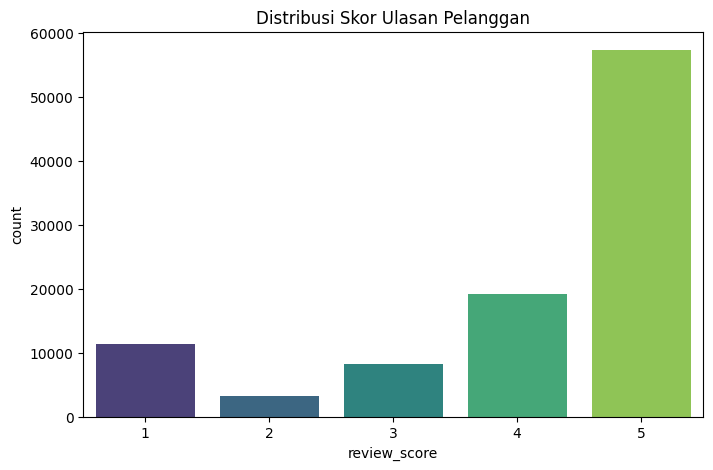

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64


In [16]:
# Distribusi Skor Ulasan
plt.figure(figsize=(8, 5))
sns.countplot(x='review_score', data=order_reviews_df, palette='viridis')
plt.title('Distribusi Skor Ulasan Pelanggan')
plt.show()

# Statistik Deskriptif Harga
print(order_items_df['price'].describe())

#### INSIGHT:

- Mayoritas pelanggan memberikan skor ulasan 5, namun terdapat porsi yang cukup signifikan untuk skor ulasan 1.

### EDA MULTIV

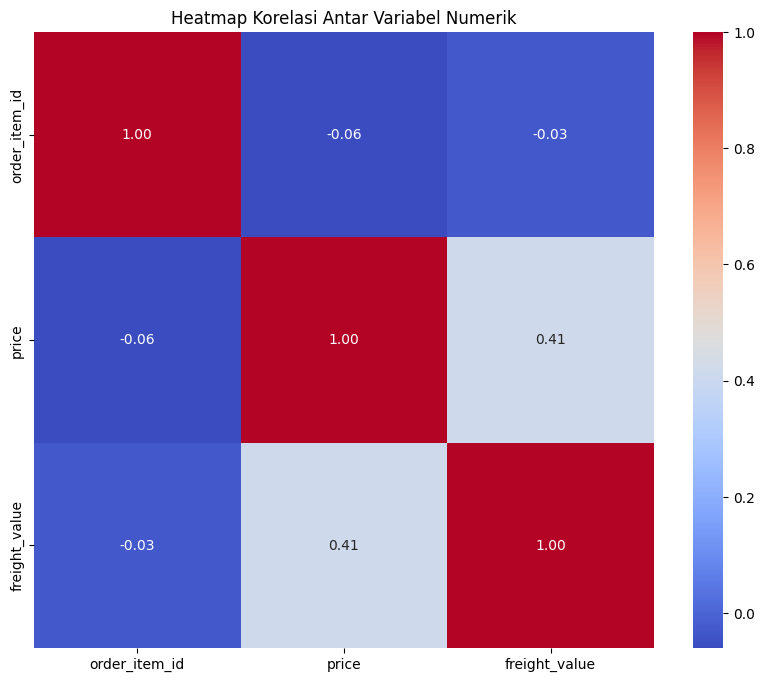

In [17]:
# Heatmap Korelasi Numerik
plt.figure(figsize=(10, 8))
numeric_df = order_items_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

In [18]:
# # Gabungkan data untuk Pertanyaan 1 (Logistik)
# delivery_analysis = pd.merge(orders_df, order_reviews_df, on="order_id")
# delivery_analysis['delivery_duration'] = (delivery_analysis['order_delivered_customer_date'] - delivery_analysis['order_purchase_timestamp']).dt.days

# # Analisis durasi vs review score (2018)
# delivery_2018 = delivery_analysis[delivery_analysis['order_purchase_timestamp'].dt.year == 2018]
# delivery_stats = delivery_2018.groupby('delivery_duration')['review_score'].mean().reset_index()

# # Gabungkan data untuk Pertanyaan 2 (Payment in Northeast)
# payment_geo = pd.merge(pd.merge(orders_df, customers_df, on="customer_id"), order_payments_df, on="order_id")
# northeast_states = ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']
# ne_q4_2017 = payment_geo[(payment_geo['customer_state'].isin(northeast_states)) & 
#                         (payment_geo['order_purchase_timestamp'].dt.year == 2017) & 
#                         (payment_geo['order_purchase_timestamp'].dt.month >= 10)]

# payment_comparison = ne_q4_2017[ne_q4_2017['payment_type'].isin(['boleto', 'credit_card'])]

**Insight:** (Opsional)
- xxx
- xxx

## Visualization & Explanatory Analysis

### Pertanyaan 1:

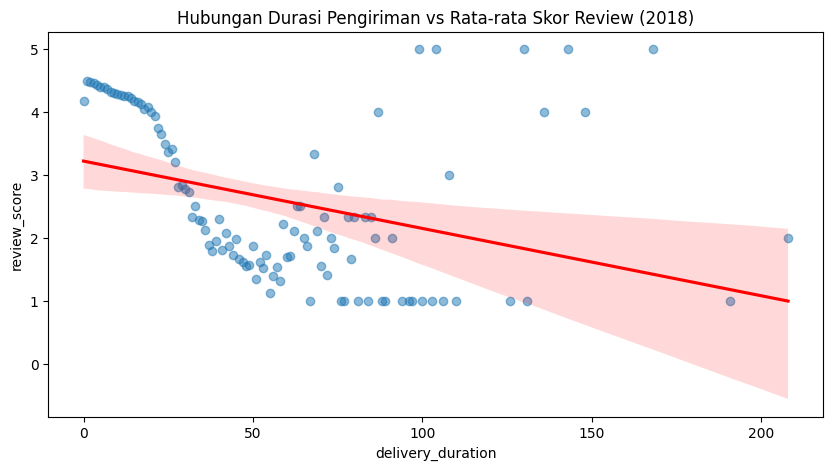

In [19]:
# Gabungkan data orders dan reviews
delivery_analysis = pd.merge(orders_df, order_reviews_df, on="order_id")
delivery_analysis['delivery_duration'] = (delivery_analysis['order_delivered_customer_date'] - delivery_analysis['order_purchase_timestamp']).dt.days

# Analisis tahun 2018
delivery_2018 = delivery_analysis[delivery_analysis['order_purchase_timestamp'].dt.year == 2018]
delivery_stats = delivery_2018.groupby('delivery_duration')['review_score'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.regplot(x='delivery_duration', y='review_score', data=delivery_stats, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Hubungan Durasi Pengiriman vs Rata-rata Skor Review (2018)')
plt.show()

### Pertanyaan 2:

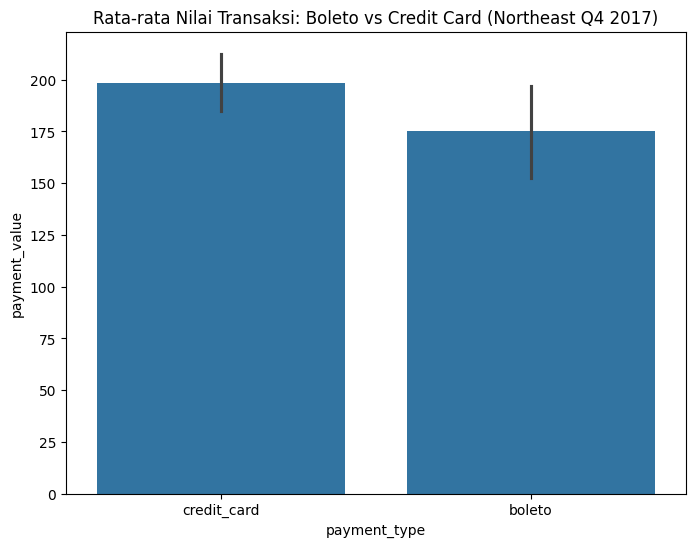

In [20]:
# Filter Wilayah Northeast dan Q4 2017
ne_states = ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']
payment_geo = pd.merge(pd.merge(orders_df, customers_df, on="customer_id"), order_payments_df, on="order_id")

ne_q4_2017 = payment_geo[
    (payment_geo['customer_state'].isin(ne_states)) & 
    (payment_geo['order_purchase_timestamp'] >= '2017-10-01') & 
    (payment_geo['order_purchase_timestamp'] <= '2017-12-31')
]

plt.figure(figsize=(8, 6))
sns.barplot(x='payment_type', y='payment_value', data=ne_q4_2017[ne_q4_2017['payment_type'].isin(['boleto', 'credit_card'])], estimator="mean")
plt.title('Rata-rata Nilai Transaksi: Boleto vs Credit Card (Northeast Q4 2017)')
plt.show()

**Insight:** (Opsional)
- xxx
- xxx

## Analisis Lanjutan (Opsional)

                            customer_id  recency  frequency  monetary
3724   0a0a92112bd4c708ca5fde585afaa872      334          1  13664.08
79633  da122df9eeddfedc1dc1f5349a1a690c      515          2   7571.63
43166  763c8b1c9c68a0229c42c9fc6f662b93       46          1   7274.88
80460  dc4802a71eae9be1dd28f5d788ceb526      563          1   6929.31
25432  459bef486812aa25204be022145caa62       35          1   6922.21


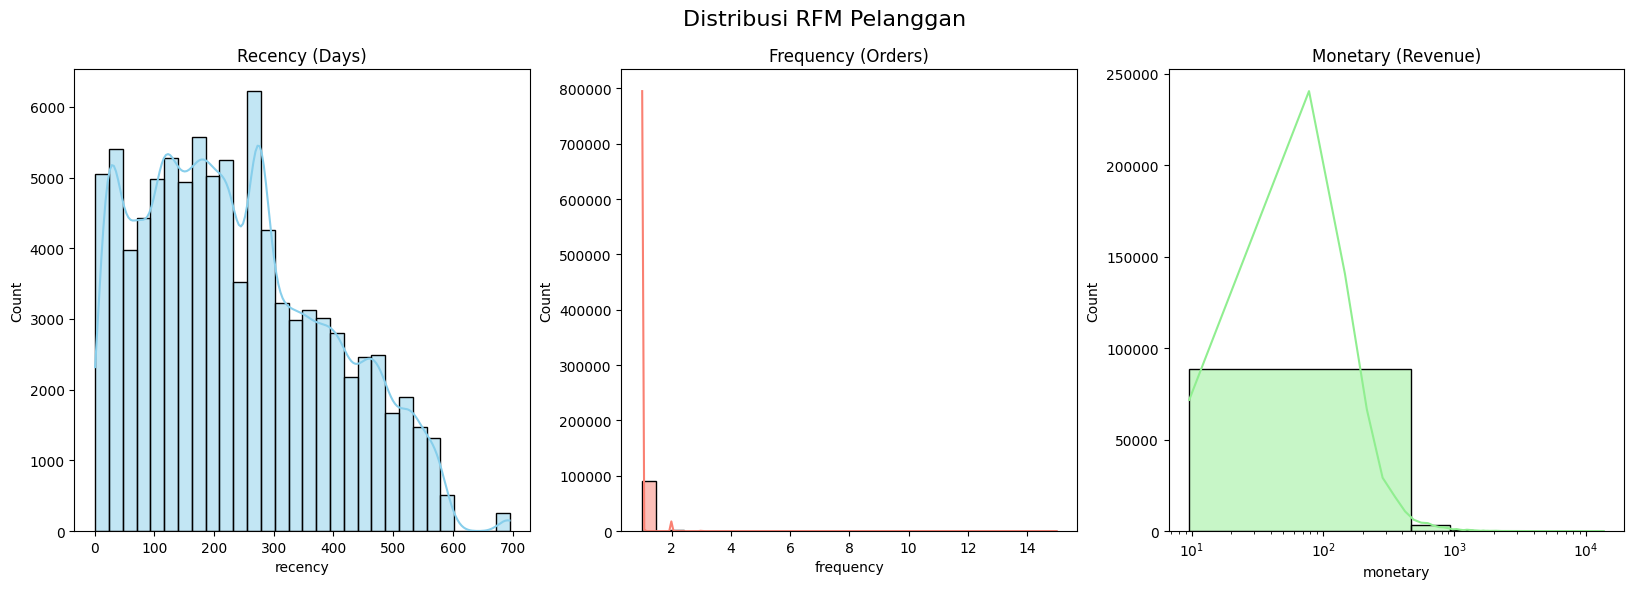

In [21]:
# Menghitung Recency, Frequency, dan Monetary
# Kita asumsikan 'current_date' adalah satu hari setelah pesanan terakhir di dataset
current_date = orders_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = payment_geo.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (current_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Menampilkan 5 pelanggan teratas berdasarkan Monetary
print(rfm_df.sort_values(by="monetary", ascending=False).head())

# Visualisasi RFM
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

sns.histplot(rfm_df['recency'], bins=30, kde=True, ax=ax[0], color="skyblue")
ax[0].set_title("Recency (Days)")

sns.histplot(rfm_df['frequency'], bins=30, kde=True, ax=ax[1], color="salmon")
ax[1].set_title("Frequency (Orders)")

sns.histplot(rfm_df['monetary'], bins=30, kde=True, ax=ax[2], color="lightgreen")
ax[2].set_title("Monetary (Revenue)")
ax[2].set_xscale('log') # Menggunakan skala log karena variasi harga yang ekstrem

plt.suptitle("Distribusi RFM Pelanggan", fontsize=16)
plt.show()

Insight:

- Recency: Mayoritas pelanggan sudah cukup lama tidak melakukan transaksi, yang mengindikasikan perlunya strategi retention atau re-engagement.  
- Frequency: Sebagian besar pelanggan hanya melakukan satu kali transaksi (one-time buyer), menunjukkan tingkat loyalitas yang masih perlu ditingkatkan.  
- Monetary: Meskipun frekuensi rendah, terdapat segelintir pelanggan "Whale" yang melakukan transaksi dengan nilai sangat tinggi (monetary tinggi).

## Conclusion & Recommendation

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Terdapat korelasi negatif antara durasi pengiriman dan skor ulasan. Skor ulasan cenderung menurun di bawah 3.0 jika pengiriman melebihi 20 hari.
- **Conclusion Pertanyaan 2:** Di wilayah Northeast pada akhir 2017, metode pembayaran 'credit_card' menghasilkan rata-rata nilai transaksi yang lebih tinggi dibandingkan 'boleto', kemungkinan karena fitur cicilan.

**Rekomendasi Action Item:**
1. **Logistik:** Mengoptimalkan rantai pasok di wilayah yang durasi pengirimannya sering melebihi 15 hari untuk menjaga tingkat kepuasan di atas 4.0.
2. **Marketing:** Memberikan promo khusus potongan biaya admin bagi pengguna 'boleto' di Northeast untuk meningkatkan minat belanja pada transaksi bernilai besar.

## KEPERLUAN DASHBOARD

In [22]:
# Simpan di sel terakhir notebook kamu (Opsional)
main_data = pd.merge(delivery_analysis, payment_geo, on="order_id", how="inner")
main_data.to_csv("dashboard/main_data.csv", index=False)